In [1]:
import argparse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
RESULTS_CSV = Path("results.csv")
OUTPUT_PATH = Path("version_comparison.png")

# consistent color-per-version across chart regenerations
VERSION_COLORS = {
    "v1_popularity": "#94a3b8",
    "v2_association": "#f87171",
    "v3_collaborative": "#34d399",
    "v4_matrix_factorization": "#60a5fa",
    "v5_neural": "#a78bfa",
}
VERSION_LABELS = {
    "v1_popularity": "V1 Popularity",
    "v2_association": "V2 Association",
    "v3_collaborative": "V3 Collaborative",
    "v4_matrix_factorization": "V4 Matrix Fact.",
    "v5_neural": "V5 Neural",
}
METRIC_LABELS = {
    "precision@10": "Precision@10",
    "recall@10": "Recall@10",
    "map@10": "MAP@10",
    "ndcg@10": "NDCG@10",
}

## Load results

In [3]:
if not RESULTS_CSV.exists():
    raise FileNotFoundError(
        f"{RESULTS_CSV} not found. Run each version's fit + evaluate_model() cell "
        "and log a row to results.csv first (see README quickstart)."
    )

df = pd.read_csv(RESULTS_CSV)
df

                   version  precision@10  recall@10  map@10  ndcg@10
0            v1_popularity        0.0428     0.0149  0.0173   0.0470
1          v2_association        0.0218     0.0106  0.0069   0.0214
2        v3_collaborative        0.0515     0.0190  0.0219   0.0574
3  v4_matrix_factorization        0.0427     0.0154  0.0178   0.0477
4               v5_neural        0.0509     0.0187  0.0218   0.0573

## Build the grouped bar chart

saved to version_comparison.png


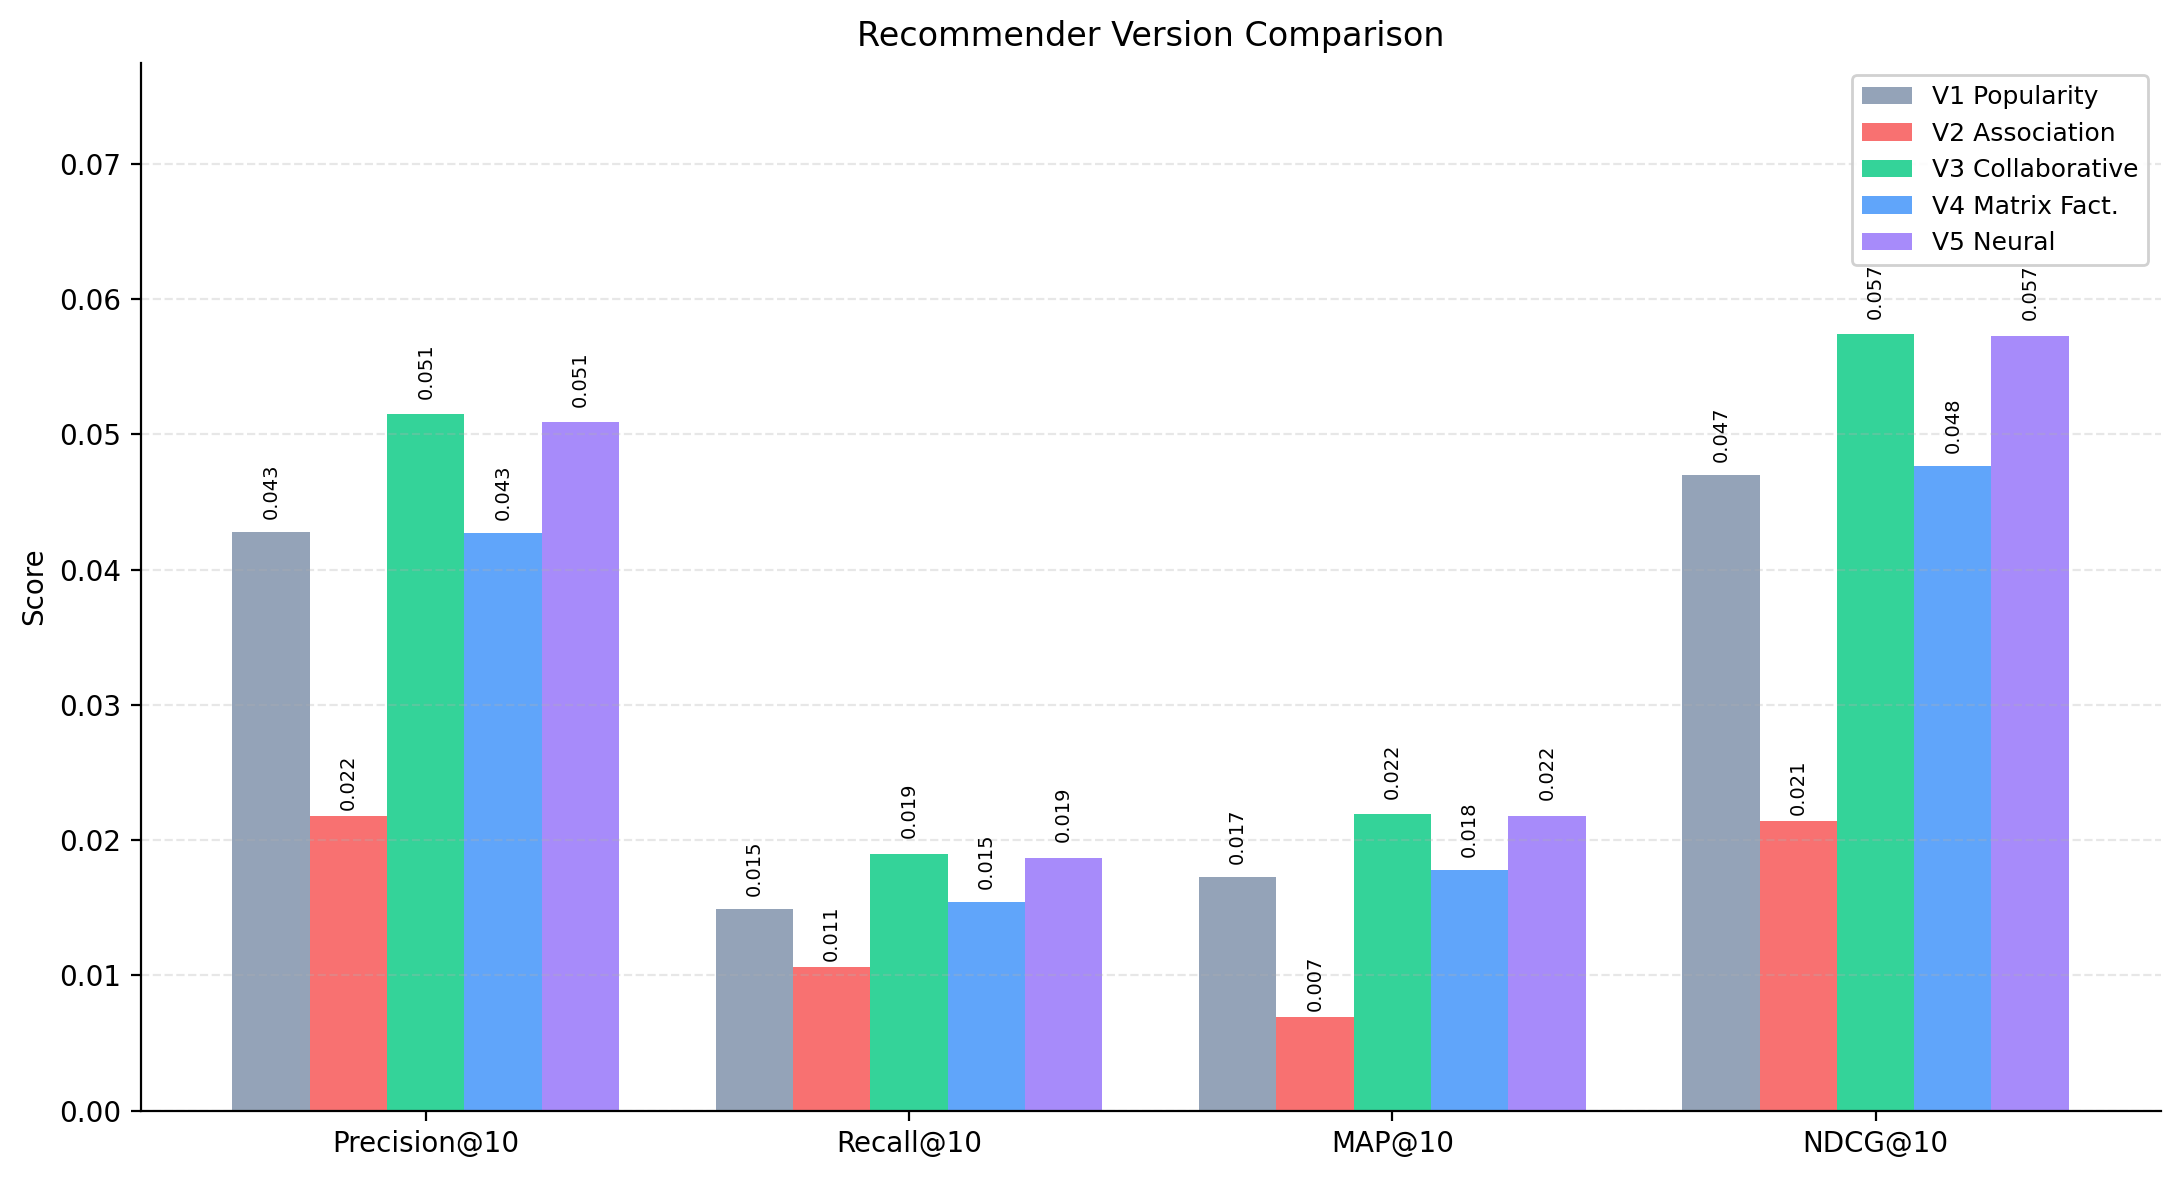

In [4]:
metrics = [c for c in df.columns if c != "version"]

versions = df["version"].tolist()
labels = [VERSION_LABELS.get(v, v) for v in versions]
colors = [VERSION_COLORS.get(v, "#999999") for v in versions]

fig, ax = plt.subplots(figsize=(11, 6))
n_versions = len(versions)
n_metrics = len(metrics)
bar_width = 0.8 / max(n_versions, 1)
x = np.arange(n_metrics)

for i, (version, label, color) in enumerate(zip(versions, labels, colors)):
    values = df.loc[df["version"] == version, metrics].values.flatten()
    offset = (i - (n_versions - 1) / 2) * bar_width
    bars = ax.bar(x + offset, values, bar_width, label=label, color=color)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7, rotation=90,
        )

ax.set_ylabel("Score")
ax.set_title("Recommender Version Comparison")
ax.set_xticks(x)
ax.set_xticklabels([METRIC_LABELS.get(m, m) for m in metrics])
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.set_ylim(0, df[metrics].values.max() * 1.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=200, bbox_inches="tight")
print(f"saved to {OUTPUT_PATH}")
plt.show()